<a href="https://colab.research.google.com/github/rahulsanjel/Aritificialintelligence/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 Worksheet 5 — End-to-End CNN Image Classifier
**Dataset:** Fruits in Amazon (6 classes: acai, cupuacu, graviola, guarana, pupunha, tucuma)

## Imports

In [22]:
import zipfile
with zipfile.ZipFile('FruitinAmazon.zip', 'r') as z:
    z.extractall('.')


In [23]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Dataset Paths

In [24]:
# Update this path to wherever you extracted the FruitinAmazon dataset
BASE_DIR  = 'FruitinAmazon'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

print("Train dir:", TRAIN_DIR)
print("Test  dir:", TEST_DIR)

Train dir: FruitinAmazon/train
Test  dir: FruitinAmazon/test


---
## Task 1 — Data Understanding and Visualisation

### 1a. Visualise one random image per class

Classes (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


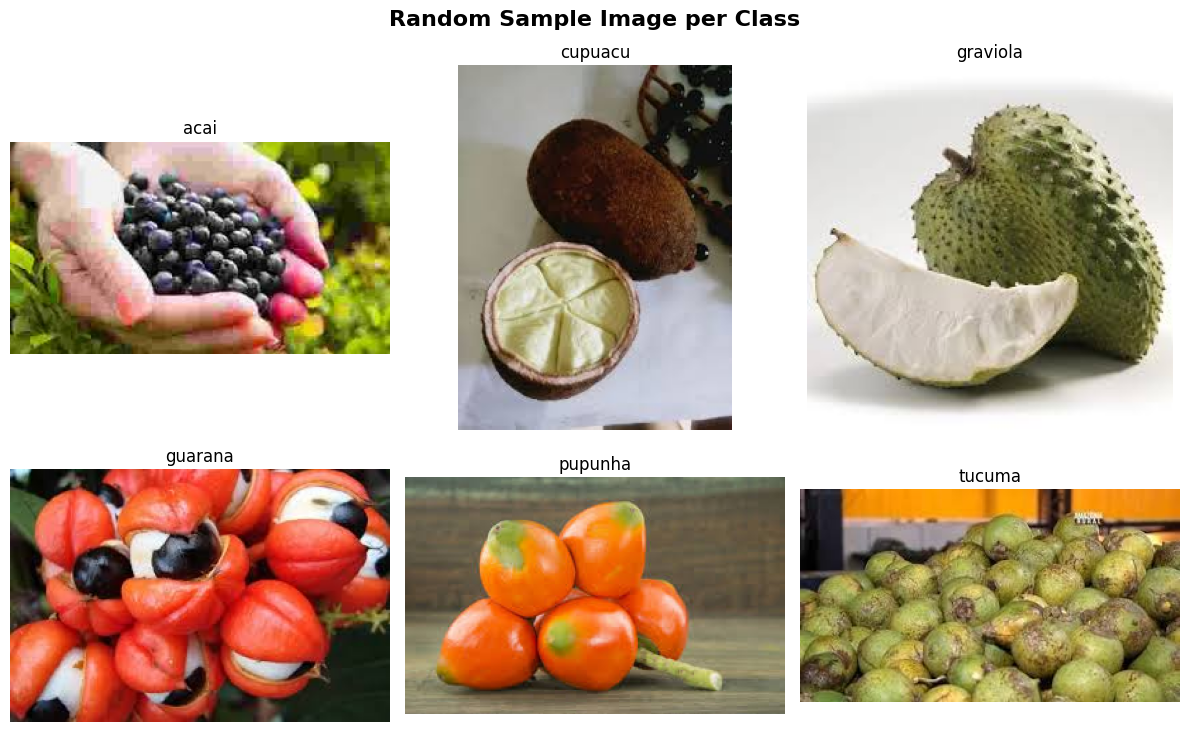

Figure saved as task1_visualisation.png


In [25]:
# Get sorted list of class directories from the train folder
class_dirs = sorted(
    [d for d in os.listdir(TRAIN_DIR)
     if os.path.isdir(os.path.join(TRAIN_DIR, d))]
)
num_classes = len(class_dirs)
print(f"Classes ({num_classes}):", class_dirs)

# Select one random image per class
sample_images = []
for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    chosen = random.choice(imgs)
    sample_images.append((cls, os.path.join(cls_path, chosen)))

# Display images in a 2-row grid
cols = 3
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
fig.suptitle('Random Sample Image per Class', fontsize=16, fontweight='bold')

for idx, (cls_name, img_path) in enumerate(sample_images):
    row, col = divmod(idx, cols)
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].set_title(cls_name, fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('task1_visualisation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved as task1_visualisation.png')

**Observation:** The dataset contains 6 distinct Amazonian fruit classes. Each class has visually different colours and textures — for example, acai berries are small and dark purple, guarana seeds are red/orange, and graviola is a large spiky green fruit. This variety should help the CNN learn discriminative features, although the small dataset size (15 training images per class) means overfitting is a significant risk.

### 1b. Check for corrupted images

In [26]:
corrupted_images = []

for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()          # Verify without fully decoding
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


---
## Task 2 — Loading and Preprocessing Image Data

In [27]:
import tensorflow as tf
print(tf.__version__)  # Should be 2.x

2.19.0


In [28]:
# Hyperparameters for data loading
IMG_HEIGHT       = 128
IMG_WIDTH        = 128
BATCH_SIZE       = 16   # as required by Task 4 training step
VALIDATION_SPLIT = 0.2  # 80/20 train-val split
SEED             = 123

# Rescaling layer — normalise [0,255] → [0,1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ── Training dataset ──────────────────────────────────────────────────────────
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED
)

# Save class names BEFORE mapping
CLASS_NAMES = train_ds_raw.class_names
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# ── Validation dataset ────────────────────────────────────────────────────────
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED
)
val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

# ── Test dataset ──────────────────────────────────────────────────────────────
test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)
test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))

print("Class names:", CLASS_NAMES)
print(f"Number of classes: {len(CLASS_NAMES)}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


---
## Task 3 — Build the CNN Model

In [29]:
num_classes = len(CLASS_NAMES)

model = keras.Sequential([
    # ── Convolutional Block 1 ──────────────────────────────────────────────────
    layers.Conv2D(
        filters=32, kernel_size=(3, 3),
        padding='same', strides=1,
        activation='relu',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Convolutional Block 2 ──────────────────────────────────────────────────
    layers.Conv2D(
        filters=32, kernel_size=(3, 3),
        padding='same', strides=1,
        activation='relu'
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Fully Connected Network ────────────────────────────────────────────────
    layers.Flatten(),
    layers.Dense(128, activation='relu'),   # Hidden Layer 1
    layers.Dense(64,  activation='relu'),   # Hidden Layer 2
    layers.Dense(num_classes, activation='softmax')  # Output Layer
], name='FruitCNN')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "FruitCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4 — Compile the Model

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


---
## Task 4 (cont.) — Train the Model

In [31]:
EPOCHS = 250

# ── Callbacks ─────────────────────────────────────────────────────────────────
checkpoint_cb = ModelCheckpoint(
    filepath='best_fruit_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=30,          # stop if val_loss does not improve for 30 epochs
    restore_best_weights=True,
    verbose=1
)

# ── Training ───────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.0924 - loss: 2.1271
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 408ms/step - accuracy: 0.0972 - loss: 2.1591 - val_accuracy: 0.0556 - val_loss: 1.6192
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.3201 - loss: 1.6733
Epoch 2: val_accuracy improved from 0.05556 to 0.55556, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.3611 - loss: 1.6403 - val_accuracy: 0.5556 - val_loss: 1.4976
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4802 - loss: 1.3937
Epoch 3: val_accuracy improved from 0.55556 to 0.83333, saving model to best_fruit_model.h5



Epoch 3: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.4583 - loss: 1.3843 - val_accuracy: 0.8333 - val_loss: 1.1169
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7125 - loss: 1.0387
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.7083 - loss: 0.9963 - val_accuracy: 0.3889 - val_loss: 1.6594
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7913 - loss: 0.7171
Epoch 5: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.7639 - loss: 0.7336 - val_accuracy: 0.7778 - val_loss: 0.7942
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7986 - loss: 0.6714
Epoch 6: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.7639 - loss: 0.7274 - val_accuracy: 0.5556 - val_loss: 1.2137
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8448 - loss:


Epoch 11: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 1.0000 - loss: 0.0330 - val_accuracy: 0.8889 - val_loss: 0.4342
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 1.0000 - loss: 0.0127
Epoch 12: val_accuracy improved from 0.88889 to 0.94444, saving model to best_fruit_model.h5



Epoch 12: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 1.0000 - loss: 0.0124 - val_accuracy: 0.9444 - val_loss: 0.3653
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 1.0000 - loss: 0.0077
Epoch 13: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 0.8889 - val_loss: 0.3200
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 1.0000 - loss: 0.0031
Epoch 14: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.8889 - val_loss: 0.3489
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 1.0000 - loss: 0.0027
Epoch 15: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8889 - val_loss: 0.3659
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000

### Training & Validation Curves

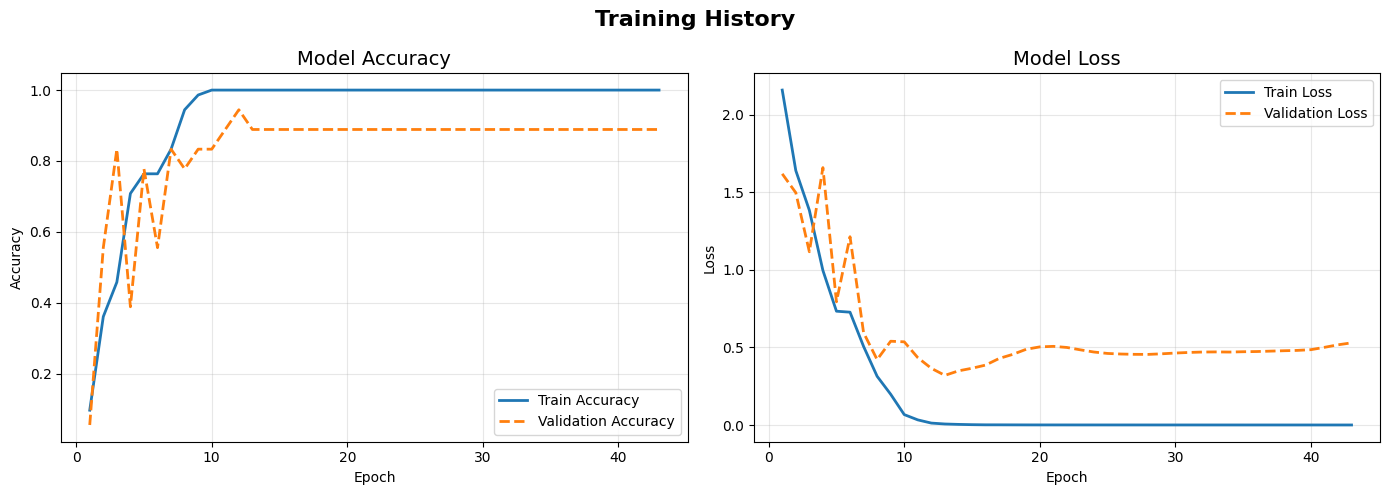

Figure saved as training_curves.png


In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Accuracy
ax1.plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy',      linewidth=2)
ax1.plot(epochs_ran, history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs_ran, history.history['loss'],     label='Train Loss',      linewidth=2)
ax2.plot(epochs_ran, history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved as training_curves.png')

---
## Task 5 — Evaluate the Model on the Test Set

In [33]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7333 - loss: 0.6698

Test Loss    : 0.6698
Test Accuracy: 0.7333  (73.33%)


---
## Task 6 — Save and Load the Model

In [34]:
# Save the current (best-weights-restored) model
model.save('fruit_cnn_final.h5')
print("Model saved to fruit_cnn_final.h5")

# Load and re-evaluate
loaded_model = keras.models.load_model('fruit_cnn_final.h5')
print("Model loaded successfully.")

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded Model — Test Loss    : {loaded_loss:.4f}")
print(f"Loaded Model — Test Accuracy: {loaded_acc:.4f}  ({loaded_acc*100:.2f}%)")

Model saved to fruit_cnn_final.h5


Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7333 - loss: 0.6698 

Loaded Model — Test Loss    : 0.6698
Loaded Model — Test Accuracy: 0.7333  (73.33%)


---
## Task 7 — Predictions and Classification Report

In [35]:
# Collect all true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

print("Predicted labels:", y_pred)
print("Actual    labels:", y_true)

Predicted labels: [0 1 0 0 0 1 2 1 1 1 2 1 2 2 2 4 3 3 3 3 4 1 4 4 4 5 2 0 5 1]
Actual    labels: [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5]


In [36]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print("\nClassification Report")
print("=" * 60)
print(report)


Classification Report
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.50      0.80      0.62         5
    graviola       0.67      0.80      0.73         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.80      0.80      0.80         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.79      0.73      0.73        30
weighted avg       0.79      0.73      0.73        30



### Visualise a sample of test predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


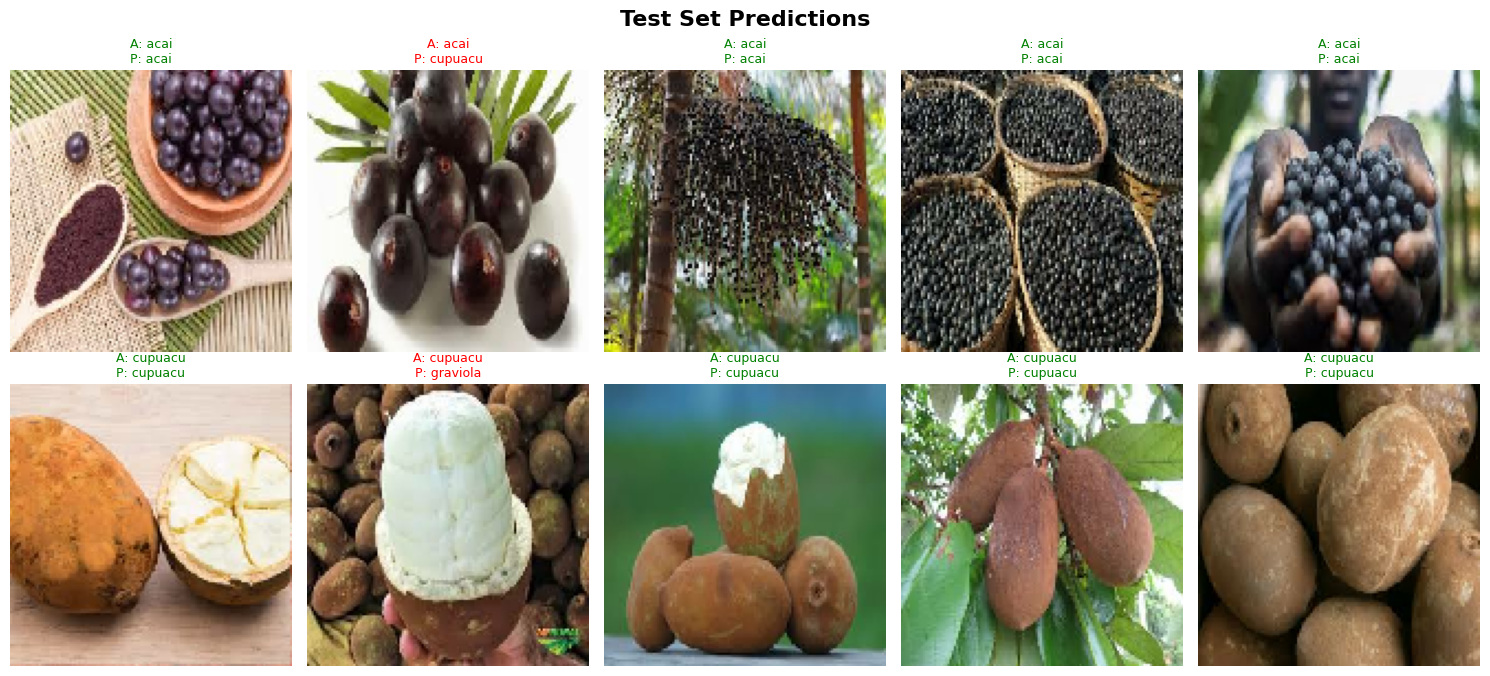

Figure saved as test_predictions.png
Green title = correct prediction | Red title = incorrect prediction


In [37]:
# Show the first 10 test images with predicted vs actual labels
test_images_list = []
test_labels_list = []

for images, labels in test_ds.take(2):
    test_images_list.extend(images.numpy())
    test_labels_list.extend(labels.numpy())

num_show = min(10, len(test_images_list))
preds_show = np.argmax(loaded_model.predict(np.array(test_images_list[:num_show])), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Test Set Predictions', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(test_images_list[i])
    actual    = CLASS_NAMES[test_labels_list[i]]
    predicted = CLASS_NAMES[preds_show[i]]
    colour    = 'green' if actual == predicted else 'red'
    ax.set_title(f'A: {actual}\nP: {predicted}', color=colour, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved as test_predictions.png')
print('Green title = correct prediction | Red title = incorrect prediction')